# Week 4 – Day 2: Baseline GNN Model Training

## Objective

Train a baseline Graph Neural Network for property-price prediction using the validated spatial graph prepared during Week 4 Day 1.

The model will use:

- Property-level node features
- Spatially connected neighboring properties
- Graph message passing

The trained model will provide the baseline GNN benchmark for the attention-based spatial model developed in Day 3.

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [4]:
BASE_DIR = Path("..")

DATA_DIR = (BASE_DIR / "data" / "processed" / "week-3" / "gnn")

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_FILE = DATA_DIR / "housing_graph_data.pt"

BEST_MODEL_FILE = (MODEL_DIR / "baseline_gnn.pt")

HISTORY_FILE = (DATA_DIR / "baseline_gnn_training_history.csv")

PREDICTION_FILE = (DATA_DIR / "baseline_gnn_predictions.csv")

In [5]:
graph_data = torch.load(GRAPH_FILE,weights_only=False)

print(graph_data)

Data(x=[21613, 24], edge_index=[2, 108065], y=[21613, 1], train_mask=[21613], val_mask=[21613], test_mask=[21613])


In [6]:
graph_data = graph_data.to(device)

print("Graph moved to:", device)
print("Nodes:", graph_data.num_nodes)
print("Features:", graph_data.num_node_features)
print("Edges:", graph_data.edge_index.shape[1])

Graph moved to: cpu
Nodes: 21613
Features: 24
Edges: 108065


In [7]:
assert graph_data.num_nodes == 21613
assert graph_data.num_node_features == 24

assert graph_data.edge_index.shape == (2,108065)

assert graph_data.y.shape == (21613,1)

assert graph_data.train_mask.sum().item() == 15129
assert graph_data.val_mask.sum().item() == 3242
assert graph_data.test_mask.sum().item() == 3242

print("✅ Graph validation passed.")

✅ Graph validation passed.


In [8]:
class BaselineGNN(nn.Module):

    def __init__(self,in_channels,hidden_channels=64,dropout=0.2):

        super().__init__()
        self.conv1 = SAGEConv(in_channels,hidden_channels)
        self.conv2 = SAGEConv(hidden_channels,hidden_channels)
        self.conv3 = SAGEConv(hidden_channels,hidden_channels)
        self.regressor = nn.Sequential(nn.Linear(hidden_channels, 32),nn.ReLU(),nn.Dropout(dropout),nn.Linear(32, 1))
        self.dropout = dropout

    def forward(self, x, edge_index):

        x = self.conv1(x,edge_index)

        x = F.relu(x)
        x = F.dropout(x,p=self.dropout,training=self.training)

        x = self.conv2(x,edge_index)

        x = F.relu(x)
        x = F.dropout(x,p=self.dropout,training=self.training)

        x = self.conv3(x,edge_index)

        x = F.relu(x)

        out = self.regressor(x)

        return out

In [9]:
model = BaselineGNN(in_channels=graph_data.num_node_features,hidden_channels=64,dropout=0.2).to(device)

print(model)

BaselineGNN(
  (conv1): SAGEConv(24, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [10]:
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", f"{trainable_parameters:,}"
)

Trainable parameters: 21,761


In [11]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)

# Standardize the target using training nodes only
y_train_values = (graph_data.y[graph_data.train_mask].detach().cpu().numpy().reshape(-1))

y_mean = y_train_values.mean()
y_std = y_train_values.std()

assert y_std > 0

y_scaled = (graph_data.y - y_mean) / y_std

graph_data.y_scaled = y_scaled

criterion = nn.MSELoss()

print(f"Training target mean: ${y_mean:,.2f}")
print(f"Training target std : ${y_std:,.2f}")
print("✅ Target scaling prepared using training data only.")

Training target mean: $513,107.09
Training target std : $251,147.53
✅ Target scaling prepared using training data only.


In [12]:
def calculate_metrics(y_true,y_pred):
    y_true = y_true.detach().cpu().numpy().reshape(-1)
    y_pred = y_pred.detach().cpu().numpy().reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    mae = mean_absolute_error(y_true,y_pred)

    mape = (mean_absolute_percentage_error(y_true,y_pred) * 100)

    r2 = r2_score(y_true,y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

In [13]:
def train_one_epoch():

    model.train()

    optimizer.zero_grad()

    predictions = model(graph_data.x,graph_data.edge_index)

    loss = criterion(predictions[graph_data.train_mask],graph_data.y_scaled[graph_data.train_mask])

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)

    optimizer.step()

    return loss.item()

In [14]:
@torch.no_grad()
def evaluate():

    model.eval()
    predictions_scaled = model(graph_data.x,graph_data.edge_index)

    # Convert predictions back to dollar prices
    predictions = (predictions_scaled * y_std) + y_mean

    train_metrics = calculate_metrics(graph_data.y[graph_data.train_mask],predictions[graph_data.train_mask])
    val_metrics = calculate_metrics(graph_data.y[graph_data.val_mask],predictions[graph_data.val_mask])
    test_metrics = calculate_metrics(graph_data.y[graph_data.test_mask],predictions[graph_data.test_mask])

    return (predictions,train_metrics,val_metrics,test_metrics)

In [15]:
EPOCHS = 300
PATIENCE = 30

best_val_rmse = float("inf")
best_state = None
patience_counter = 0

history = []

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch()
    predictions, train_metrics, val_metrics, test_metrics = evaluate()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_rmse": train_metrics["RMSE"],
        "val_rmse": val_metrics["RMSE"],
        "val_mape": val_metrics["MAPE"]
    })

    if val_metrics["RMSE"] < best_val_rmse:
        best_val_rmse = val_metrics["RMSE"]
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:,.2f} | "
            f"Train RMSE: ${train_metrics['RMSE']:,.2f} | "
            f"Val RMSE: ${val_metrics['RMSE']:,.2f} | "
            f"Val MAPE: {val_metrics['MAPE']:.2f}%"
        )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

Epoch 001 | Train Loss: 1.00 | Train RMSE: $248,144.65 | Val RMSE: $248,783.23 | Val MAPE: 52.95%
Epoch 010 | Train Loss: 0.73 | Train RMSE: $204,209.73 | Val RMSE: $205,016.76 | Val MAPE: 44.40%
Epoch 020 | Train Loss: 0.39 | Train RMSE: $142,074.09 | Val RMSE: $150,094.84 | Val MAPE: 23.68%
Epoch 030 | Train Loss: 0.29 | Train RMSE: $119,874.24 | Val RMSE: $119,874.97 | Val MAPE: 21.25%
Epoch 040 | Train Loss: 0.24 | Train RMSE: $110,182.51 | Val RMSE: $108,888.93 | Val MAPE: 18.29%
Epoch 050 | Train Loss: 0.22 | Train RMSE: $106,436.99 | Val RMSE: $104,929.73 | Val MAPE: 18.42%
Epoch 060 | Train Loss: 0.21 | Train RMSE: $102,432.13 | Val RMSE: $101,043.48 | Val MAPE: 17.37%
Epoch 070 | Train Loss: 0.20 | Train RMSE: $99,418.56 | Val RMSE: $98,080.63 | Val MAPE: 16.62%
Epoch 080 | Train Loss: 0.19 | Train RMSE: $97,271.24 | Val RMSE: $95,767.72 | Val MAPE: 16.29%
Epoch 090 | Train Loss: 0.18 | Train RMSE: $95,167.47 | Val RMSE: $93,744.55 | Val MAPE: 15.94%
Epoch 100 | Train Loss: 0.

In [16]:
assert best_state is not None

model.load_state_dict(best_state)

print("✅ Best validation model restored.")

print(
    f"Best validation RMSE: "
    f"${best_val_rmse:,.2f}"
)

✅ Best validation model restored.
Best validation RMSE: $79,574.98


In [17]:
final_predictions, final_train_metrics, final_val_metrics, final_test_metrics = evaluate()

print("=" * 60)
print("BASELINE GNN FINAL RESULTS")
print("=" * 60)

print("\nTraining:")
print(f"RMSE: ${final_train_metrics['RMSE']:,.2f}")
print(f"MAPE: {final_train_metrics['MAPE']:.2f}%")
print(f"R²: {final_train_metrics['R2']:.4f}")

print("\nValidation:")
print(f"RMSE: ${final_val_metrics['RMSE']:,.2f}")
print(f"MAPE: {final_val_metrics['MAPE']:.2f}%")
print(f"R²: {final_val_metrics['R2']:.4f}")

print("\nTest:")
print(f"RMSE: ${final_test_metrics['RMSE']:,.2f}")
print(f"MAPE: {final_test_metrics['MAPE']:.2f}%")
print(f"R²: {final_test_metrics['R2']:.4f}")

BASELINE GNN FINAL RESULTS

Training:
RMSE: $77,712.08
MAPE: 12.39%
R²: 0.9043

Validation:
RMSE: $79,574.98
MAPE: 13.01%
R²: 0.9001

Test:
RMSE: $80,285.81
MAPE: 12.32%
R²: 0.8905


In [18]:
history_df = pd.DataFrame(history)

history_df.to_csv(HISTORY_FILE,index=False)

print("✅ Training history saved:")
print(HISTORY_FILE)

✅ Training history saved:
..\data\processed\week-3\gnn\baseline_gnn_training_history.csv


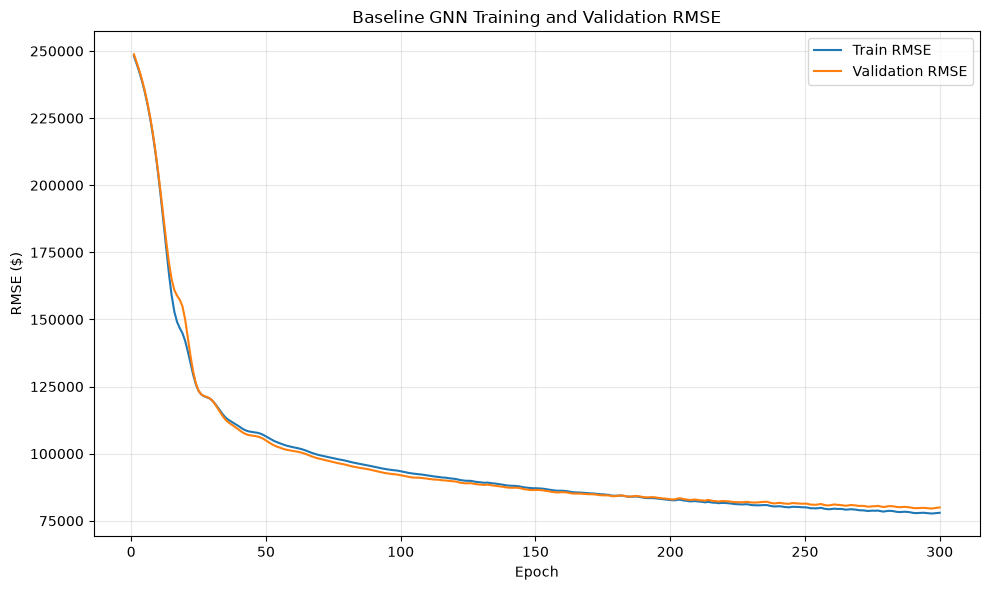

✅ Saved: ..\data\processed\week-3\gnn\baseline_gnn_training_curve.png


In [19]:
plot_path = (DATA_DIR / "baseline_gnn_training_curve.png")

plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"],history_df["train_rmse"],label="Train RMSE")

plt.plot(history_df["epoch"],history_df["val_rmse"],label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE ($)")
plt.title("Baseline GNN Training and Validation RMSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(plot_path,dpi=150,bbox_inches="tight")

plt.show()

print("✅ Saved:",plot_path)

In [20]:
# Create node indices for the prediction output
node_ids = np.arange(graph_data.num_nodes)

print("Number of node IDs:", len(node_ids))

Number of node IDs: 21613


In [21]:
# Create prediction results
prediction_df = pd.DataFrame({
    "node_id": node_ids,
    "actual_price": graph_data.y.cpu().numpy().reshape(-1),
    "predicted_price": final_predictions.cpu().numpy().reshape(-1)
})

prediction_df["absolute_error"] = (prediction_df["actual_price"] - prediction_df["predicted_price"]).abs()

prediction_df["percentage_error"] = (prediction_df["absolute_error"] / prediction_df["actual_price"]) * 100

prediction_df.head()

,node_id,actual_price,predicted_price,absolute_error,percentage_error
0,0,221900.0,285976.28125,64076.28125,28.876198
1,1,538000.0,527245.12500,10754.87500,1.999047
2,2,180000.0,314874.65625,134874.65625,74.930367
3,3,604000.0,473440.84375,130559.15625,21.615753
4,4,510000.0,510273.96875,273.96875,0.053719


In [22]:
prediction_df.to_csv(PREDICTION_FILE,index=False)

print("✅ GNN predictions saved:")
print(PREDICTION_FILE)

✅ GNN predictions saved:
..\data\processed\week-3\gnn\baseline_gnn_predictions.csv


In [23]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_class": "BaselineGNN",
        "input_features": graph_data.num_node_features,
        "hidden_channels": 64,
        "dropout": 0.2,
        "seed": SEED,
        "best_val_rmse": best_val_rmse
    },
    MODEL_DIR / "baseline_gnn.pt"
)

print("✅ Baseline GNN model saved.")

✅ Baseline GNN model saved.


In [24]:
assert len(prediction_df) == graph_data.num_nodes

assert prediction_df["predicted_price"].notna().all()

assert np.isfinite(prediction_df["predicted_price"]).all()

assert history_df["val_rmse"].notna().all()

assert os.path.exists(MODEL_DIR / "baseline_gnn.pt")

assert os.path.exists(PREDICTION_FILE)

print("=" * 60)
print("WEEK 4 DAY 2 VALIDATION")
print("=" * 60)

print(f"Graph nodes: {graph_data.num_nodes:,}")

print(f"Graph edges: " f"{graph_data.edge_index.shape[1]:,}")

print(f"Best validation RMSE: " f"${best_val_rmse:,.2f}")

print(f"Test RMSE: " f"${final_test_metrics['RMSE']:,.2f}")

print(f"Test MAPE: " f"{final_test_metrics['MAPE']:.2f}%")

print(f"Test R²: " f"{final_test_metrics['R2']:.4f}")

print("\n✅ Baseline GNN training completed successfully.")

WEEK 4 DAY 2 VALIDATION
Graph nodes: 21,613
Graph edges: 108,065
Best validation RMSE: $79,574.98
Test RMSE: $80,285.81
Test MAPE: 12.32%
Test R²: 0.8905

✅ Baseline GNN training completed successfully.
